In [1]:
# !pip install -U transformers
# !pip install -U accelerate
# !pip install -U datasets
# !pip install -U bertviz
# !pip install -U umap-learn
# !pip install -U sentencepiece
# !pip install -U urllib3
# !pip install py7zr
# !pip install -U pillow

# Image classification

## Load Dog and Cats dataset

Start by loading a smaller subset of the Food-101 dataset from the 🤗 Datasets library. This will give you a chance to
experiment and make sure everything works before spending more time training on the full dataset.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from datasets import load_dataset

dataset = load_dataset("microsoft/cats_vs_dogs", split=['train'], trust_remote_code=True, ignore_verifications=True)


In [3]:
dataset
dataset = dataset[0].train_test_split(test_size=0.3, seed=42)

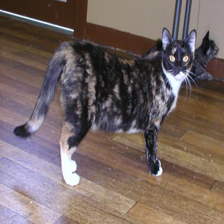

In [9]:
dataset["train"][0]['image'].size
dataset["train"][0]['image']

In [6]:
# resize the images to 224x224
def resize_image(example, size=(224, 224)):
    image = example['image']
    image = image.resize(size)
    example['image'] = image
    return example

dataset = dataset.map(resize_image)

Each example in the dataset has two fields:

- `image`: a PIL image of the food item
- `label`: the label class of the food item

To make it easier for the model to get the label name from the label id, create a dictionary that maps the label name
to an integer and vice versa:

In [10]:
labels = dataset["train"].features["labels"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label


Now you can convert the label id to a label name:

In [11]:
print(id2label)
print(label2id)

{'0': 'cat', '1': 'dog'}
{'cat': '0', 'dog': '1'}


## Preprocess

The next step is to load a ViT image processor to process the image into a tensor:

In [13]:
from transformers import AutoImageProcessor
import torch

# https://huggingface.co/google/vit-base-patch16-224-in21k

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(checkpoint, use_fast=True)

Now create a batch of examples using [DefaultDataCollator](https://huggingface.co/docs/transformers/main/en/main_classes/data_collator#transformers.DefaultDataCollator). Unlike other data collators in 🤗 Transformers, the `DefaultDataCollator` does not apply additional preprocessing such as padding.

In [14]:
from transformers import DefaultDataCollator

data_collator = DefaultDataCollator()

## Evaluate

Including a metric during training is often helpful for evaluating your model's performance. You can quickly load an
evaluation method with the 🤗 [Evaluate](https://huggingface.co/docs/evaluate/index) library. For this task, load
the [accuracy](https://huggingface.co/spaces/evaluate-metric/accuracy) metric (see the 🤗 Evaluate [quick tour](https://huggingface.co/docs/evaluate/a_quick_tour) to learn more about how to load and compute a metric):

In [15]:
import evaluate

accuracy = evaluate.load("accuracy")

Then create a function that passes your predictions and labels to [compute](https://huggingface.co/docs/evaluate/main/en/package_reference/main_classes#evaluate.EvaluationModule.compute) to calculate the accuracy:

In [16]:
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

Your `compute_metrics` function is ready to go now, and you'll return to it when you set up your training.

## Train

<Tip>

If you aren't familiar with finetuning a model with the [Trainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer), take a look at the basic tutorial [here](https://huggingface.co/docs/transformers/main/en/tasks/../training#train-with-pytorch-trainer)!

</Tip>

You're ready to start training your model now! Load ViT with [AutoModelForImageClassification](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForImageClassification). Specify the number of labels along with the number of expected labels, and the label mappings:

In [17]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
).to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


At this point, only three steps remain:

1. Define your training hyperparameters in [TrainingArguments](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments). It is important you don't remove unused columns because that'll drop the `image` column. Without the `image` column, you can't create `pixel_values`. Set `remove_unused_columns=False` to prevent this behavior! The only other required parameter is `output_dir` which specifies where to save your model. You'll push this model to the Hub by setting `push_to_hub=True` (you need to be signed in to Hugging Face to upload your model). At the end of each epoch, the [Trainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) will evaluate the accuracy and save the training checkpoint.
2. Pass the training arguments to [Trainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) along with the model, dataset, tokenizer, data collator, and `compute_metrics` function.
3. Call [train()](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

In [18]:
from torchvision.transforms import RandomResizedCrop, Compose, Normalize, ToTensor

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
size = (
    image_processor.size["shortest_edge"]
    if "shortest_edge" in image_processor.size
    else (image_processor.size["height"], image_processor.size["width"])
)
_transforms = Compose([RandomResizedCrop(size), ToTensor(), normalize])

def transforms(examples):
    examples["pixel_values"] = [_transforms(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples

dataset = dataset.with_transform(transforms)

In [19]:
training_args = TrainingArguments(
    output_dir="dog_cat_classification",
    remove_unused_columns=False,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1000,
    num_train_epochs=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
)

trainer.train()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/440 [00:00<?, ?it/s]

{'eval_loss': 0.655974268913269, 'eval_accuracy': 0.6904795787676107, 'eval_runtime': 79.2933, 'eval_samples_per_second': 88.62, 'eval_steps_per_second': 5.549, 'epoch': 0.98}
{'train_runtime': 498.8646, 'train_samples_per_second': 32.865, 'train_steps_per_second': 0.002, 'train_loss': 0.7005758285522461, 'epoch': 0.98}


TrainOutput(global_step=1, training_loss=0.7005758285522461, metrics={'train_runtime': 498.8646, 'train_samples_per_second': 32.865, 'train_steps_per_second': 0.002, 'total_flos': 1.239871833833472e+18, 'train_loss': 0.7005758285522461, 'epoch': 0.975609756097561})

In [20]:
trainer.evaluate()

  0%|          | 0/440 [00:00<?, ?it/s]

{'eval_loss': 0.6555168032646179,
 'eval_accuracy': 0.6943219012380817,
 'eval_runtime': 78.7294,
 'eval_samples_per_second': 89.255,
 'eval_steps_per_second': 5.589,
 'epoch': 0.975609756097561}

In [21]:
trainer.save_model("dog_cat_classification")

## Inference

Great, now that you've fine-tuned a model, you can use it for inference!

Load an image you'd like to run inference on:

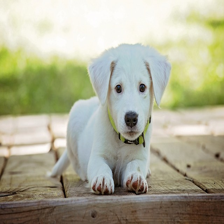

In [26]:
# load dog image from online url

import requests
from PIL import Image
from io import BytesIO

url = "https://cdn.pixabay.com/photo/2016/12/13/05/15/puppy-1903313_640.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

# show in 300x300
image = image.resize((224, 224))
image

In [29]:
from transformers import pipeline

classifier = pipeline("image-classification", model="dog_cat_classification", device=device)
classifier(image)

[{'label': 'dog', 'score': 0.5687971115112305},
 {'label': 'cat', 'score': 0.43120288848876953}]